# Using 6th place winner's approaches to the problem. Thank you to Artem for posting his write up and being a big inspiration for this model.

In [1]:
# %% ============================================================
# CELL 1: Imports & Configuration
# ===============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import gc
import time
from pathlib import Path
from scipy.stats import spearmanr
 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
 
warnings.filterwarnings("ignore")
 
# ── Paths ─────────────────────────────────────────────────────
DATA_PATH = Path("data")
 
# ── Hyperparameters ───────────────────────────────────────────
WINDOW_SIZE      = 50       # lookback window (Artem used 50)
HIDDEN_SIZE      = 256      # LSTM hidden dim (Artem used 256)
NUM_LAYERS       = 1        # single layer LSTM
DROPOUT          = 0.1      # light dropout for simple model
LEARNING_RATE    = 1e-3     # Adam lr (Artem used 1e-3)
EPOCHS           = 25       # Artem used 25
BATCH_SIZE       = 64
PATIENCE         = 10       # early stopping
N_SEEDS          = 3        # ensemble seeds
RECURSIVE_STEPS  = 5        # predict 5 days ahead
LAG_BLEND_ALPHA  = 0.7      # blend: alpha*lag_mean + (1-alpha)*model
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
# %% ============================================================
# CELL 2: Load Data
# ===============================================================
train        = pd.read_csv(DATA_PATH / "train.csv").sort_values("date_id").reset_index(drop=True)
train_labels = pd.read_csv(DATA_PATH / "train_labels.csv").sort_values("date_id").reset_index(drop=True)
test         = pd.read_csv(DATA_PATH / "test.csv").sort_values("date_id").reset_index(drop=True)
ground_truth = pd.read_csv(DATA_PATH / "test_ground_truth.csv").sort_values("date_id").reset_index(drop=True)
target_pairs = pd.read_csv(DATA_PATH / "target_pairs.csv")
 
# Load lag files for lag correction blending
lag_dfs = {}
for lag in [1, 2, 3, 4]:
    lag_path = DATA_PATH / f"test_labels_lag_{lag}.csv"
    if lag_path.exists():
        lag_dfs[lag] = pd.read_csv(lag_path)
        print(f"  Loaded lag {lag}: {lag_dfs[lag].shape}")
 
if "is_scored" in test.columns:
    is_scored = test["is_scored"].copy()
    test = test.drop(columns=["is_scored"])
 
feature_cols = [c for c in train.columns if c != "date_id"]
target_cols  = [c for c in train_labels.columns if c != "date_id"]
n_features   = len(feature_cols)
 
# Identify which columns are needed for target derivation
needed_assets = set()
for _, row in target_pairs.iterrows():
    pair = row["pair"]
    if " - " in pair:
        a, b = pair.split(" - ", 1)
        needed_assets.add(a.strip())
        needed_assets.add(b.strip())
    else:
        needed_assets.add(pair.strip())
asset_cols = sorted([c for c in needed_assets if c in feature_cols])
 
# Map asset names to their index in feature_cols
asset_to_idx = {col: feature_cols.index(col) for col in asset_cols}
 
print(f"\nTrain: {train.shape}")
print(f"Test:  {test.shape}")
print(f"Features: {n_features}")
print(f"Targets: {len(target_cols)}")
print(f"Assets for target derivation: {len(asset_cols)}")

  Loaded lag 1: (134, 108)
  Loaded lag 2: (134, 108)
  Loaded lag 3: (134, 108)
  Loaded lag 4: (134, 108)

Train: (1961, 558)
Test:  (134, 558)
Features: 557
Targets: 424
Assets for target derivation: 106


In [3]:
# %% ============================================================
# CELL 3: Preprocessing (StandardScaler, mean imputation)
# ===============================================================
# Use only training dates (before test period) for fitting scaler
train_only = train[train["date_id"] < 1827].copy()
 
# Fill missing values with global training mean
train_means = train_only[feature_cols].mean()
 
train_filled = train[feature_cols].fillna(train_means).values.astype(np.float32)
test_filled  = test[feature_cols].fillna(train_means).values.astype(np.float32)
 
# StandardScaler (Z-score normalization, as Artem used)
scaler = StandardScaler()
scaler.fit(train_filled[:len(train_only)])  # fit on training dates only
 
train_scaled = scaler.transform(train_filled)
test_scaled  = scaler.transform(test_filled)
 
# Also keep unscaled prices for target derivation later
train_prices = train_filled.copy()
test_prices  = test_filled.copy()
 
print(f"Scaled train: {train_scaled.shape}")
print(f"Scaled test:  {test_scaled.shape}")

Scaled train: (1961, 557)
Scaled test:  (134, 557)


In [4]:
# %% ============================================================
# CELL 4: Dataset — predict NEXT DAY'S features
# ===============================================================
class FeatureForecastDataset(Dataset):
    """
    Input:  window of scaled features [t-W+1 : t]
    Target: scaled features at [t+1] (next day)
    """
    def __init__(self, scaled_features, window_size):
        self.features = scaled_features.astype(np.float32)
        self.window = window_size
 
    def __len__(self):
        return len(self.features) - self.window
 
    def __getitem__(self, idx):
        x = self.features[idx : idx + self.window]      # (window, n_features)
        y = self.features[idx + self.window]              # (n_features,) — NEXT DAY
        return torch.from_numpy(x), torch.from_numpy(y)

In [5]:
# %% ============================================================
# CELL 5: Feature Forecasting LSTM
# ===============================================================
class FeatureForecastLSTM(nn.Module):
    """
    Many-to-One LSTM that predicts the next day's feature state.
    Architecture follows Artem's: Input -> LSTM -> Linear -> Output
    Input and output dimensions are both n_features (predicting features).
    """
    def __init__(self, n_features, hidden_size=256, num_layers=1, dropout=0.1):
        super().__init__()
 
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
 
        self.head = nn.Linear(hidden_size, n_features)
 
    def forward(self, x):
        # x: (batch, window, n_features)
        lstm_out, _ = self.lstm(x)
        last = lstm_out[:, -1, :]           # (batch, hidden)
        return self.head(last)              # (batch, n_features)

In [6]:
# %% ============================================================
# CELL 6: Training Loop
# ===============================================================
def train_model(model, train_loader, val_loader, epochs, lr, patience, device, label=""):
    """Train with MSE on feature values."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=patience // 3, factor=0.5
    )
 
    best_val_loss = float("inf")
    best_state = None
    wait = 0
    history = {"train_loss": [], "val_loss": []}
 
    for epoch in range(epochs):
        # ── Train ─────────────────────────────────────────────
        model.train()
        train_losses = []
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
 
            pred = model(x_batch)
            loss = nn.functional.mse_loss(pred, y_batch)
 
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
 
            train_losses.append(loss.item())
 
        # ── Validate ──────────────────────────────────────────
        model.eval()
        val_losses = []
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                pred = model(x_batch)
                loss = nn.functional.mse_loss(pred, y_batch)
                val_losses.append(loss.item())
 
        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
 
        scheduler.step(val_loss)
 
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
            marker = " ★"
        else:
            wait += 1
            marker = ""
 
        if (epoch + 1) % 5 == 0 or marker:
            lr_now = optimizer.param_groups[0]["lr"]
            print(f"  [{label}] Epoch {epoch+1:3d}/{epochs}  "
                  f"train={train_loss:.6f}  val={val_loss:.6f}  "
                  f"lr={lr_now:.1e}{marker}")
 
        if wait >= patience:
            print(f"  [{label}] Early stopping at epoch {epoch+1}")
            break
 
    model.load_state_dict(best_state)
    model.to(device)
    print(f"  [{label}] Best val loss: {best_val_loss:.6f}")
    return model, history

In [7]:
# %% ============================================================
# CELL 7: Train Ensemble
# ===============================================================
# Split: train on dates 0-1576 (85%), validate on 1577-1826 (15%)
val_split = int(len(train_only) * 0.85)
print(f"Train samples: {val_split - WINDOW_SIZE}")
print(f"Val samples: {len(train_only) - val_split}")
print(f"Features: {n_features}")
print()
 
# Only train on data before test period
train_data = train_scaled[:len(train_only)]
 
models = []
histories = []
 
for seed_idx in range(N_SEEDS):
    seed = 42 + seed_idx * 111
    torch.manual_seed(seed)
    np.random.seed(seed)
 
    print(f"\n{'='*55}")
    print(f"Seed {seed_idx+1}/{N_SEEDS} (seed={seed})")
    print(f"{'='*55}")
 
    # Datasets
    train_ds = FeatureForecastDataset(train_data[:val_split], WINDOW_SIZE)
    val_ds   = FeatureForecastDataset(train_data[val_split - WINDOW_SIZE:], WINDOW_SIZE)
 
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
 
    model = FeatureForecastLSTM(
        n_features=n_features,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
    ).to(DEVICE)
 
    if seed_idx == 0:
        n_params = sum(p.numel() for p in model.parameters())
        print(f"Parameters: {n_params:,}")
 
    model, hist = train_model(
        model, train_loader, val_loader,
        epochs=EPOCHS, lr=LEARNING_RATE, patience=PATIENCE,
        device=DEVICE, label=f"s{seed_idx}",
    )
 
    models.append(model)
    histories.append(hist)
 
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Train samples: 1502
Val samples: 275
Features: 557


Seed 1/3 (seed=42)
Parameters: 977,709
  [s0] Epoch   1/25  train=0.426081  val=1.097903  lr=1.0e-03 ★
  [s0] Epoch   2/25  train=0.222721  val=0.998428  lr=1.0e-03 ★
  [s0] Epoch   3/25  train=0.189170  val=0.935057  lr=1.0e-03 ★
  [s0] Epoch   5/25  train=0.162278  val=0.935261  lr=1.0e-03
  [s0] Epoch   6/25  train=0.155711  val=0.918345  lr=1.0e-03 ★
  [s0] Epoch   7/25  train=0.149206  val=0.908151  lr=1.0e-03 ★
  [s0] Epoch   8/25  train=0.145630  val=0.898791  lr=1.0e-03 ★
  [s0] Epoch  10/25  train=0.139575  val=0.938375  lr=1.0e-03
  [s0] Epoch  11/25  train=0.135299  val=0.884860  lr=1.0e-03 ★
  [s0] Epoch  15/25  train=0.125323  val=0.953201  lr=5.0e-04
  [s0] Epoch  20/25  train=0.116017  val=0.963679  lr=2.5e-04
  [s0] Early stopping at epoch 21
  [s0] Best val loss: 0.884860

Seed 2/3 (seed=153)
  [s1] Epoch   1/25  train=0.437720  val=1.086562  lr=1.0e-03 ★
  [s1] Epoch   2/25  train=0.223933  val=1.028738  lr=1.0e-03 

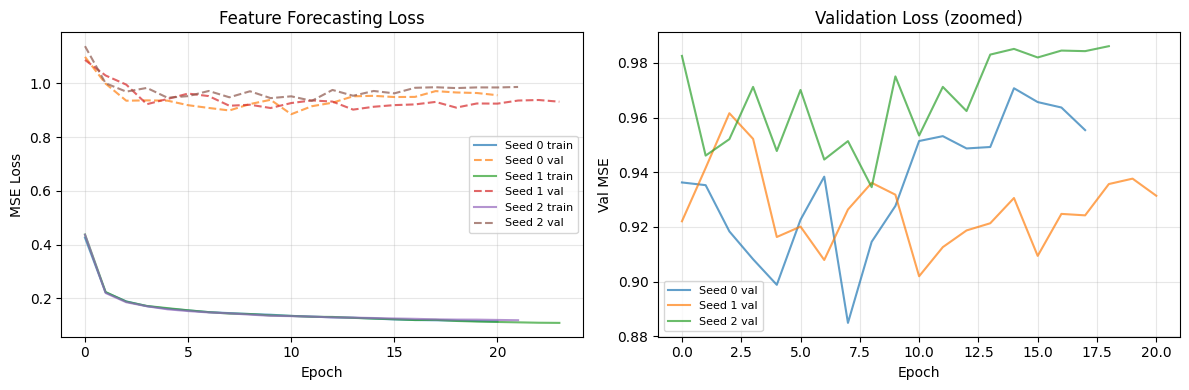

In [8]:
# %% ============================================================
# CELL 8: Plot Training History
# ===============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
for s, hist in enumerate(histories):
    axes[0].plot(hist["train_loss"], label=f"Seed {s} train", alpha=0.7)
    axes[0].plot(hist["val_loss"], label=f"Seed {s} val", linestyle="--", alpha=0.7)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Feature Forecasting Loss")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
 
# Zoom into later epochs
for s, hist in enumerate(histories):
    start = min(3, len(hist["val_loss"]) - 1)
    axes[1].plot(hist["val_loss"][start:], label=f"Seed {s} val", alpha=0.7)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val MSE")
axes[1].set_title("Validation Loss (zoomed)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig("training_feature_forecast.png", dpi=150)
plt.show()

In [9]:
# %% ============================================================
# CELL 9: Recursive Inference — Predict 5 Days Ahead
# ===============================================================
def recursive_forecast(model, initial_window_scaled, n_steps, scaler, device):
    """
    Recursively predict n_steps days ahead.
 
    Args:
        model: trained LSTM
        initial_window_scaled: (window_size, n_features) scaled features
        n_steps: how many days to forecast
        scaler: fitted StandardScaler (to inverse-transform predictions)
 
    Returns:
        predicted_prices: (n_steps, n_features) in ORIGINAL scale
    """
    model.eval()
    window = initial_window_scaled.copy()  # (window_size, n_features)
    predictions_scaled = []
 
    with torch.no_grad():
        for step in range(n_steps):
            x = torch.FloatTensor(window).unsqueeze(0).to(device)  # (1, window, feat)
            pred_scaled = model(x).cpu().numpy()[0]                 # (n_features,)
            predictions_scaled.append(pred_scaled)
 
            # Roll window: drop oldest day, append prediction
            window = np.vstack([window[1:], pred_scaled.reshape(1, -1)])
 
    predictions_scaled = np.array(predictions_scaled)  # (n_steps, n_features)
 
    # Inverse transform to original price scale
    predicted_prices = scaler.inverse_transform(predictions_scaled)
 
    return predicted_prices
 
 
def derive_targets_from_prices(current_prices, predicted_prices, target_pairs_df,
                                feature_cols, asset_to_idx):
    """
    Compute target values from predicted future prices.
 
    For each target:
      - Get the lag (1-4) and pair info
      - Single: target = log(price[lag] / price[0])
        where price[0] is predicted day+1, price[lag] is predicted day+1+lag
        Actually: target at date d = log(price[d+1+lag] / price[d+1])
        So we need: price at d+1 = predicted_prices[0]
                    price at d+1+lag = predicted_prices[lag]
      - Pair: target = log(A[lag]/A[0]) - log(B[lag]/B[0])
 
    Args:
        current_prices: prices at date d (the last known day) — NOT USED
        predicted_prices: (5, n_features) predicted prices for d+1 to d+5
        target_pairs_df: DataFrame with target, lag, pair columns
        feature_cols: list of feature column names
        asset_to_idx: dict mapping asset name to index in feature array
 
    Returns:
        targets: dict of {target_name: predicted_value}
    """
    targets = {}
 
    for _, row in target_pairs_df.iterrows():
        target_name = row["target"]
        lag = row["lag"]
        pair = row["pair"]
 
        if " - " in pair:
            a, b = pair.split(" - ", 1)
            a, b = a.strip(), b.strip()
 
            if a not in asset_to_idx or b not in asset_to_idx:
                targets[target_name] = 0.0
                continue
 
            idx_a = asset_to_idx[a]
            idx_b = asset_to_idx[b]
 
            # Price at d+1 (first predicted day)
            pa_0 = predicted_prices[0, idx_a]
            pb_0 = predicted_prices[0, idx_b]
            # Price at d+1+lag
            pa_lag = predicted_prices[lag, idx_a] if lag < len(predicted_prices) else predicted_prices[-1, idx_a]
            pb_lag = predicted_prices[lag, idx_b] if lag < len(predicted_prices) else predicted_prices[-1, idx_b]
 
            # Avoid log of zero/negative
            if pa_0 <= 0 or pa_lag <= 0 or pb_0 <= 0 or pb_lag <= 0:
                targets[target_name] = 0.0
                continue
 
            target_val = np.log(pa_lag / pa_0) - np.log(pb_lag / pb_0)
 
        else:
            asset = pair.strip()
            if asset not in asset_to_idx:
                targets[target_name] = 0.0
                continue
 
            idx = asset_to_idx[asset]
            p_0 = predicted_prices[0, idx]
            p_lag = predicted_prices[lag, idx] if lag < len(predicted_prices) else predicted_prices[-1, idx]
 
            if p_0 <= 0 or p_lag <= 0:
                targets[target_name] = 0.0
                continue
 
            target_val = np.log(p_lag / p_0)
 
        targets[target_name] = target_val
 
    return targets

In [10]:
# Quick debug: check if target derivation is correct
# Pick a date where we know the actual prices and actual targets
d = 1830  # a test date
d_idx = train[train["date_id"] == d].index[0]

# Actual future prices from train
actual_prices = train_filled[d_idx+1 : d_idx+6]  # days d+1 to d+5

# Derive targets using actual prices
actual_targets = derive_targets_from_prices(
    None, actual_prices, target_pairs, feature_cols, asset_to_idx
)

# Compare with ground truth
gt_row = ground_truth[ground_truth["date_id"] == d].iloc[0]

matches, mismatches = 0, 0
for t in list(actual_targets.keys())[:20]:
    pred_val = actual_targets[t]
    true_val = gt_row[t]
    if np.isnan(true_val):
        continue
    diff = abs(pred_val - true_val)
    if diff < 0.001:
        matches += 1
    else:
        mismatches += 1
        print(f"  {t}: derived={pred_val:.6f}, truth={true_val:.6f}, diff={diff:.6f}")

print(f"\nMatches: {matches}, Mismatches: {mismatches}")


Matches: 20, Mismatches: 0


In [11]:
# %% ============================================================
# CELL 10: Generate Predictions for Test Set
# ===============================================================
print("Generating recursive predictions for test set...")
t0 = time.time()
 
# We need the full price history leading into the test period
# train_scaled covers dates 0-1960, test starts at date 1827
# Find where test dates begin in the training data
test_start_date = test["date_id"].min()
test_start_idx = train[train["date_id"] == test_start_date].index[0]
 
all_seed_predictions = []
 
for seed_idx, model in enumerate(models):
    print(f"\n  Seed {seed_idx}: predicting {len(test)} test dates...")
    seed_predictions = []
 
    for i, test_date in enumerate(test["date_id"].values):
        # Get the window of WINDOW_SIZE days ending at this test date
        # Use train_scaled which has the full history
        train_idx = train[train["date_id"] == test_date].index[0]
 
        if train_idx < WINDOW_SIZE:
            # Not enough history, use zeros
            seed_predictions.append({t: 0.0 for t in target_cols})
            continue
 
        # Window of scaled features ending at (and including) this date
        window = train_scaled[train_idx - WINDOW_SIZE + 1 : train_idx + 1]
 
        # Recursive forecast: predict 5 days ahead
        predicted_prices = recursive_forecast(
            model, window, RECURSIVE_STEPS, scaler, DEVICE
        )
 
        # Derive targets from predicted prices
        targets = derive_targets_from_prices(
            current_prices=None,
            predicted_prices=predicted_prices,
            target_pairs_df=target_pairs,
            feature_cols=feature_cols,
            asset_to_idx=asset_to_idx,
        )
 
        seed_predictions.append(targets)
 
    seed_df = pd.DataFrame(seed_predictions)
    seed_df.insert(0, "date_id", test["date_id"].values)
    all_seed_predictions.append(seed_df)
    print(f"  Seed {seed_idx}: done")
 
# Ensemble average
pred_df = all_seed_predictions[0].copy()
for col in target_cols:
    values = np.mean([df[col].values for df in all_seed_predictions], axis=0)
    pred_df[col] = values
 
print(f"\nPredictions generated in {time.time()-t0:.1f}s")
print(f"Shape: {pred_df.shape}")

Generating recursive predictions for test set...

  Seed 0: predicting 134 test dates...
  Seed 0: done

  Seed 1: predicting 134 test dates...
  Seed 1: done

  Seed 2: predicting 134 test dates...
  Seed 2: done

Predictions generated in 11.1s
Shape: (134, 425)


In [12]:
# %% ============================================================
# CELL 11: Lag Correction (Artem's Key Trick)
# ===============================================================
def apply_lag_correction(pred_df, lag_dfs, target_pairs_df, alpha=0.7, lookback=5):
    """
    API-style lag correction: at test date t, only use lag label rows
    whose release date_id <= t.
    
    Lag-L file row i has release date_id = test_date[i] + (L+1).
    So at test row i, we can use lag-L rows up to i-(L+1).
    This means we shift by (L+1) for each lag.
    """
    corrected = pred_df.copy()
    
    for lag in [1, 2, 3, 4]:
        if lag not in lag_dfs:
            continue
        
        lag_df = lag_dfs[lag].reset_index(drop=True)
        lag_targets = target_pairs_df.loc[
            target_pairs_df["lag"] == lag, "target"
        ].tolist()
        available = [t for t in lag_targets if t in lag_df.columns and t in corrected.columns]
        
        # Shift by (lag + 1) to respect release timing
        api_shift = lag + 1
        rolling_mean = lag_df[available].shift(api_shift).rolling(lookback, min_periods=1).mean()
        
        for target in available:
            lag_vals = rolling_mean[target].values
            model_vals = corrected[target].values
            
            mask = ~np.isnan(lag_vals)
            blended = model_vals.copy()
            blended[mask] = alpha * lag_vals[mask] + (1 - alpha) * model_vals[mask]
            corrected[target] = blended
    
    return corrected

print("Applying lag correction (API-style timing)...")
pred_corrected = apply_lag_correction(pred_df, lag_dfs, target_pairs, alpha=LAG_BLEND_ALPHA)
print("Done")

Applying lag correction (API-style timing)...
Done


In [13]:
# Debug: check if lag correction actually changed anything
diff = (pred_corrected[target_cols].values - pred_df[target_cols].values)
print(f"Max difference after lag correction: {np.nanmax(np.abs(diff)):.10f}")
print(f"Non-zero diffs: {(np.abs(diff) > 1e-10).sum()}")

# Check if lag files have data
for lag in [1, 2, 3, 4]:
    lag_df = lag_dfs[lag]
    lag_targets = target_pairs.loc[target_pairs["lag"] == lag, "target"].tolist()
    available = [t for t in lag_targets if t in lag_df.columns]
    non_null = lag_df[available].notna().sum().sum()
    print(f"Lag {lag}: {len(available)} targets, {non_null} non-null values")

# Check a specific target
test_target = target_pairs.iloc[0]["target"]
print(f"\nTarget: {test_target}")
print(f"  pred_df first 5:       {pred_df[test_target].values[:5]}")
print(f"  pred_corrected first 5: {pred_corrected[test_target].values[:5]}")
print(f"  lag_1 first 5:          {lag_dfs[1][test_target].values[:5]}")

Max difference after lag correction: 0.2805586755
Non-zero diffs: 54966
Lag 1: 106 targets, 12791 non-null values
Lag 2: 106 targets, 12748 non-null values
Lag 3: 106 targets, 12747 non-null values
Lag 4: 106 targets, 12814 non-null values

Target: target_0
  pred_df first 5:       [0.02509206 0.01207132 0.02413093 0.02513744 0.03064113]
  pred_corrected first 5: [0.02509206 0.01207132 0.02413093 0.00933342 0.01195963]
  lag_1 first 5:          [            nan  2.56026707e-03  5.34626466e-03  8.23059494e-05
 -1.14685329e-02]


In [14]:
print("lag_dfs keys:", list(lag_dfs.keys()))
print("lag_dfs type:", {k: type(k) for k in lag_dfs.keys()})
print("Number of lag files loaded:", len(lag_dfs))

lag_dfs keys: [1, 2, 3, 4]
lag_dfs type: {1: <class 'int'>, 2: <class 'int'>, 3: <class 'int'>, 4: <class 'int'>}
Number of lag files loaded: 4


In [15]:
# %% ============================================================
# CELL 12: Competition Metric
# ===============================================================
def competition_score(pred_df, gt_df, target_cols, silent=False):
    """Exact replication of Kaggle grading metric."""
    pred = pred_df[target_cols].copy()
    gt   = gt_df[target_cols].copy()
 
    daily_corrs = []
    for i in range(len(pred)):
        gt_row = gt.iloc[i]
        pred_row = pred.iloc[i]
 
        valid = gt_row.notna()
        if valid.sum() < 2:
            continue
 
        gt_valid = gt_row[valid]
        pred_valid = pred_row[valid]
 
        if gt_valid.std(ddof=0) == 0 or pred_valid.std(ddof=0) == 0:
            continue
 
        corr = np.corrcoef(
            pred_valid.rank(method="average"),
            gt_valid.rank(method="average")
        )[0, 1]
        daily_corrs.append(corr)
 
    daily_corrs = np.array(daily_corrs)
    if len(daily_corrs) == 0 or daily_corrs.std(ddof=0) == 0:
        return 0.0, daily_corrs
 
    sharpe = daily_corrs.mean() / daily_corrs.std(ddof=0)
 
    if not silent:
        print(f"  Daily rank corr: mean={daily_corrs.mean():.4f}, "
              f"std={daily_corrs.std():.4f}, Sharpe={sharpe:.4f}, "
              f"days={len(daily_corrs)}")
 
    return sharpe, daily_corrs

In [16]:
# %% ============================================================
# CELL 13: Evaluate
# ===============================================================
gt = ground_truth.copy()
 
# ── Without lag correction ────────────────────────────────────
print("=" * 55)
print("MODEL ONLY (no lag correction):")
print("=" * 55)
sharpe_raw, daily_raw = competition_score(pred_df, gt, target_cols)
 
# ── With lag correction ───────────────────────────────────────
print(f"\nWITH LAG CORRECTION (alpha={LAG_BLEND_ALPHA}):")
print("=" * 55)
sharpe_corrected, daily_corrected = competition_score(pred_corrected, gt, target_cols)
 
# ── Scored dates only ─────────────────────────────────────────
scored_dates = test.loc[is_scored, "date_id"].values
gt_scored = gt[gt["date_id"].isin(scored_dates)].reset_index(drop=True)
 
pred_raw_scored = pred_df[pred_df["date_id"].isin(scored_dates)].reset_index(drop=True)
pred_corr_scored = pred_corrected[pred_corrected["date_id"].isin(scored_dates)].reset_index(drop=True)
 
print(f"\nSCORED DATES — Model only:")
s1, _ = competition_score(pred_raw_scored, gt_scored, target_cols)
print(f"SCORED DATES — With lag correction:")
s2, _ = competition_score(pred_corr_scored, gt_scored, target_cols)
 
# ── Per-lag breakdown ─────────────────────────────────────────
print("\nPer-target Spearman (with lag correction):")
for lag in [1, 2, 3, 4]:
    lag_targets = target_pairs.loc[target_pairs["lag"] == lag, "target"].tolist()
    corrs = []
    for col in lag_targets:
        mask = gt[col].notna()
        if mask.sum() < 5:
            continue
        c, _ = spearmanr(pred_corrected.loc[mask, col], gt.loc[mask, col])
        corrs.append(c)
    pos = sum(1 for c in corrs if c > 0)
    print(f"  Lag {lag}: mean={np.nanmean(corrs):.4f}, positive={pos}/{len(corrs)}")

MODEL ONLY (no lag correction):
  Daily rank corr: mean=0.0431, std=0.2134, Sharpe=0.2021, days=134

WITH LAG CORRECTION (alpha=0.7):
  Daily rank corr: mean=0.0030, std=0.1909, Sharpe=0.0158, days=134

SCORED DATES — Model only:
  Daily rank corr: mean=0.0327, std=0.2276, Sharpe=0.1436, days=90
SCORED DATES — With lag correction:
  Daily rank corr: mean=0.0068, std=0.1849, Sharpe=0.0368, days=90

Per-target Spearman (with lag correction):
  Lag 1: mean=-0.0586, positive=19/106
  Lag 2: mean=-0.0526, positive=36/106
  Lag 3: mean=-0.0813, positive=28/106
  Lag 4: mean=-0.0919, positive=30/106


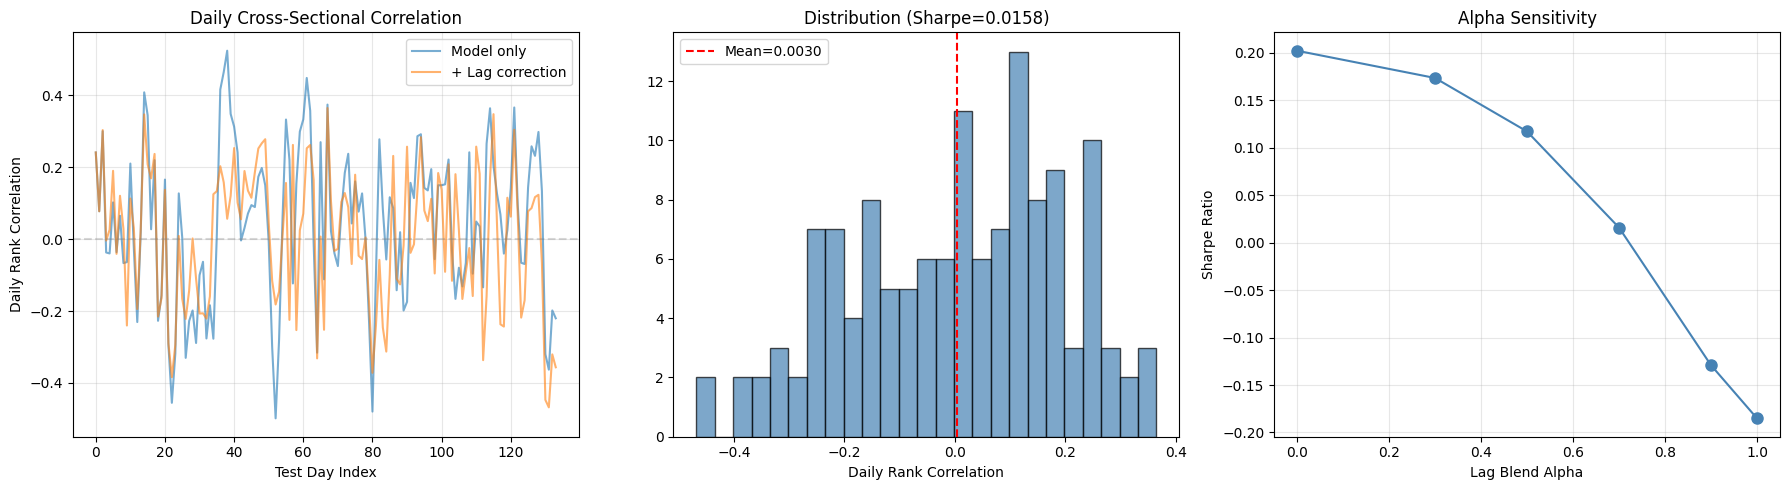


Best alpha from sweep: 0.0 (Sharpe=0.2021)


In [19]:
# %% ============================================================
# CELL 14: Visualize
# ===============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# Daily correlations comparison
axes[0].plot(daily_raw, label="Model only", alpha=0.6)
axes[0].plot(daily_corrected, label="+ Lag correction", alpha=0.6)
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.3)
axes[0].set_xlabel("Test Day Index")
axes[0].set_ylabel("Daily Rank Correlation")
axes[0].set_title("Daily Cross-Sectional Correlation")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 
# Histogram
axes[1].hist(daily_corrected, bins=25, edgecolor="black", alpha=0.7, color="steelblue")
axes[1].axvline(daily_corrected.mean(), color="red", linestyle="--",
                label=f"Mean={daily_corrected.mean():.4f}")
axes[1].set_xlabel("Daily Rank Correlation")
axes[1].set_title(f"Distribution (Sharpe={sharpe_corrected:.4f})")
axes[1].legend()
 
# Alpha sensitivity (quick test)
alphas = [0.0, 0.3, 0.5, 0.7, 0.9, 1.0]
alpha_scores = []
for a in alphas:
    pred_a = apply_lag_correction(pred_df, lag_dfs, target_pairs, alpha=a)
    s, _ = competition_score(pred_a, gt, target_cols, silent=True)
    alpha_scores.append(s)
 
axes[2].plot(alphas, alpha_scores, "o-", color="steelblue", markersize=8)
axes[2].set_xlabel("Lag Blend Alpha")
axes[2].set_ylabel("Sharpe Ratio")
axes[2].set_title("Alpha Sensitivity")
axes[2].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig("results_feature_forecast.png", dpi=150)
plt.show()
 
print(f"\nBest alpha from sweep: {alphas[np.argmax(alpha_scores)]}"
      f" (Sharpe={max(alpha_scores):.4f})")

In [20]:
# Save raw model predictions (no lag correction) for ensemble
pred_df.to_csv("predictions_feature_forecast_raw.csv", index=False)
print(f"Saved raw predictions: {pred_df.shape}")

Saved raw predictions: (134, 425)
